<a href="https://colab.research.google.com/github/Shaithra2107/HALT-RAG/blob/lift_signal/compute_lift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets sentence-transformers faiss-cpu -q
from datasets import load_dataset
ds = load_dataset("akariasai/PopQA")
print(ds['test'][0])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 49.0 MB/s eta 0:00:00


README.md:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


test.tsv:   0%|          | 0.00/5.21M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/14267 [00:00<?, ? examples/s]

{'id': 4222362, 'subj': 'George Rankin', 'prop': 'occupation', 'obj': 'politician', 'subj_id': 1850297, 'prop_id': 22, 'obj_id': 2834605, 's_aliases': '["George James Rankin"]', 'o_aliases': '["political leader","political figure","polit.","pol"]', 's_uri': 'http://www.wikidata.org/entity/Q5543720', 'o_uri': 'http://www.wikidata.org/entity/Q82955', 's_wiki_title': 'George Rankin', 'o_wiki_title': 'Politician', 's_pop': 142, 'o_pop': 25692, 'question': "What is George Rankin's occupation?", 'possible_answers': '["politician", "political leader", "political figure", "polit.", "pol"]'}


## Load Wikipedia passage corpus

In [ ]:
from datasets import load_dataset

print("loading passages...")
corpus = load_dataset(
    "rag-datasets/rag-mini-wikipedia",
    "text-corpus",
    split="passages"
)

passages = [item['passage'] for item in corpus]
print(f"loaded {len(passages)} passages")
print(f"sample: {passages[0][:200]}")

loading passages...


README.md:   0%|          | 0.00/719 [00:00<?, ?B/s]

data/passages.parquet/part.0.parquet: reconstructing file:   0%|          |  0.00B /  797kB            

data/passages.parquet/part.0.parquet: downloading bytes:           |  0.00B            

Generating passages split:   0%|          | 0/3200 [00:00<?, ? examples/s]

loaded 3200 passages
sample: Uruguay (official full name in  ; pron.  , Eastern Republic of  Uruguay) is a country located in the southeastern part of South America.  It is home to 3.3 million people, of which 1.7 million live in


# Embed passages and build FAISS index

In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

print("loading embedding model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

print("embedding 3200 passages — takes about 1-2 minutes...")
passage_embeddings = embedder.encode(
    passages,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"embedding shape: {passage_embeddings.shape}")

# normalise for cosine similarity
faiss.normalize_L2(passage_embeddings)

# build index
dimension = passage_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(passage_embeddings.astype('float32'))

print(f"FAISS index ready — {index.ntotal} passages indexed")

loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

embedding 3200 passages — takes about 1-2 minutes...


Batches:   0%|          | 0/50 [00:00<?, ?it/s]

embedding shape: (3200, 384)
FAISS index ready — 3200 passages indexed


In [ ]:
def retrieve(query, k=5):
    q_vec = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_vec)
    scores, indices = index.search(q_vec.astype('float32'), k)

    return [
        {'text': passages[idx], 'score': float(score)}
        for score, idx in zip(scores[0], indices[0])
    ]

# quick test
test_q = ds['test'][0]['question']
docs = retrieve(test_q)
print(f"question: {test_q}")
print(f"top doc score: {docs[0]['score']:.4f}")
print(f"top doc preview: {docs[0]['text'][:200]}")

question: What is George Rankin's occupation?
top doc score: 0.4249
top doc preview: *Brinkley, Alan, and Davis Dyer. The American Presidency. Boston: Houghton Mifflin company, 2004.


In [ ]:
from transformers import pipeline
import torch

print("loading generator...")
generator = pipeline(
    "text-generation",
    model="distilgpt2",
    device=0 if torch.cuda.is_available() else -1
)
generator.tokenizer.pad_token = generator.tokenizer.eos_token
print("generator ready")

def naive_rag(question, k=5):
    docs = retrieve(question, k=k)
    context = " ".join([d['text'] for d in docs])[:800]
    prompt = f"Context: {context}\nQ: {question}\nA:"

    result = generator(
        prompt,
        max_new_tokens=15,
        do_sample=False,
        pad_token_id=generator.tokenizer.eos_token_id
    )
    full = result[0]['generated_text']
    answer = full.split("A:")[-1].strip().split('\n')[0].strip()
    return answer

# test
q = ds['test'][0]['question']
ans = naive_rag(q)
print(f"question:  {q}")
print(f"predicted: {ans}")
print(f"gold:      {ds['test'][0]['possible_answers']}")

loading generator...


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


generator ready


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


question:  What is George Rankin's occupation?
predicted: He was a chemist and chemist at the time of the Revolution. He was
gold:      ["politician", "political leader", "political figure", "polit.", "pol"]


In [ ]:
import json

def exact_match(predicted, possible_answers):
    answers = json.loads(possible_answers) if isinstance(possible_answers, str) else possible_answers
    pred_lower = predicted.lower().strip()
    return any(ans.lower().strip() in pred_lower for ans in answers)

print("measuring naive RAG baseline on 100 questions...")
results = []
correct = 0

# fix: use index instead of slice
for i in range(100):
    item = ds['test'][i]          # ← this is the fix

    predicted = naive_rag(item['question'])
    is_correct = exact_match(predicted, item['possible_answers'])

    if is_correct:
        correct += 1

    results.append({
        'question':   item['question'],
        'predicted':  predicted,
        'correct':    is_correct,
        'popularity': item['s_pop'],
        'is_tail':    item['s_pop'] < 100
    })

    if (i+1) % 20 == 0:
        print(f"  {i+1}/100 — accuracy so far: {correct/(i+1):.1%}")

tail = [r for r in results if r['is_tail']]
head = [r for r in results if not r['is_tail']]
tail_acc = sum(r['correct'] for r in tail) / len(tail) if tail else 0
head_acc = sum(r['correct'] for r in head) / len(head) if head else 0

print(f"\n{'='*45}")
print(f"  NAIVE RAG BASELINE — 100 questions")
print(f"{'='*45}")
print(f"  overall accuracy : {correct/100:.1%}")
print(f"  head entities    : {head_acc:.1%}  ({len(head)} questions)")
print(f"  tail entities    : {tail_acc:.1%}  ({len(tail)} questions)")
print(f"  head - tail gap  : {head_acc - tail_acc:.1%}")
print(f"{'='*45}")
print(f"  this gap is what READ-RAG targets")

[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


measuring naive RAG baseline on 100 questions...


[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  20/100 — accuracy so far: 5.0%


[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

...

  60/100 — accuracy so far: 3.3%


[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  80/100 — accuracy so far: 2.5%


[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

  100/100 — accuracy so far: 2.0%

  NAIVE RAG BASELINE — 100 questions
  overall accuracy : 2.0%
  head entities    : 2.6%  (77 questions)
  tail entities    : 0.0%  (23 questions)
  head - tail gap  : 2.6%
  this gap is what READ-RAG targets


In [ ]:
# look at 5 examples to understand the failure mode
print("SAMPLE PREDICTIONS vs GOLD ANSWERS\n")
for r in results[:5]:
    print(f"Q:         {r['question']}")
    print(f"predicted: {r['predicted']}")
    print(f"correct:   {r['correct']}")
    print(f"popularity:{r['popularity']} views {'(TAIL)' if r['is_tail'] else '(HEAD)'}")
    print()

SAMPLE PREDICTIONS vs GOLD ANSWERS

Q:         What is George Rankin's occupation?
predicted: He was a chemist and chemist at the time of the Revolution. He was
correct:   False
popularity:142 views (HEAD)

Q:         What is John Mayne's occupation?
predicted: John Mayne was a merchant in the United States. He was a merchant
correct:   False
popularity:236 views (HEAD)

Q:         What is Henry Feilden's occupation?
predicted: Henry Feilden was a farmer in the United States. He was a
correct:   False
popularity:58 views (TAIL)

Q:         What is Kathy Saltzman's occupation?
predicted: Kathy Saltzman is a former secretary of the Department of Education. She was
correct:   False
popularity:127 views (HEAD)

Q:         What is Eleanor Davis's occupation?
predicted: She was born in the United States. She was born in the United States
correct:   False
popularity:317 views (HEAD)



In [ ]:
# RETRIEVAL HIT RATE — better metric for your research
# checks if correct answer appears in retrieved docs
# doesn't depend on generator quality at all
import json

print("measuring retrieval hit rate...")
retrieval_hits = []

for i in range(100):
    item = ds['test'][i]
    question = item['question']
    answers = json.loads(item['possible_answers'])
    popularity = item['s_pop']

    # retrieve docs
    docs = retrieve(question, k=5)
    all_retrieved_text = " ".join([d['text'] for d in docs]).lower()

    # check if any correct answer appears in retrieved docs
    hit = any(ans.lower() in all_retrieved_text for ans in answers)

    retrieval_hits.append({
        'hit': hit,
        'popularity': popularity,
        'is_tail': popularity < 100,
        'top_score': docs[0]['score']
    })

tail_hits = [r for r in retrieval_hits if r['is_tail']]
head_hits = [r for r in retrieval_hits if not r['is_tail']]

tail_hit_rate = sum(r['hit'] for r in tail_hits) / len(tail_hits) if tail_hits else 0
head_hit_rate = sum(r['hit'] for r in head_hits) / len(head_hits) if head_hits else 0

print(f"\n{'='*50}")
print(f"  RETRIEVAL HIT RATE — 100 questions")
print(f"  (does correct answer appear in retrieved docs?)")
print(f"{'='*50}")
print(f"  head entities : {head_hit_rate:.1%}  ({len(head_hits)} questions)")
print(f"  tail entities : {tail_hit_rate:.1%}  ({len(tail_hits)} questions)")
print(f"  gap           : {head_hit_rate - tail_hit_rate:.1%}")
print(f"{'='*50}")
print(f"  this gap = corpus coverage failure")
print(f"  this is exactly what lift signal detects")

measuring retrieval hit rate...

  RETRIEVAL HIT RATE — 100 questions
  (does correct answer appear in retrieved docs?)
  head entities : 13.0%  (77 questions)
  tail entities : 8.7%  (23 questions)
  gap           : 4.3%
  this gap = corpus coverage failure
  this is exactly what lift signal detects


In [ ]:
import random
import numpy as np

def compute_lift(query, retrieved_docs, corpus_passages, n_random=50):
    """
    NOVEL CONTRIBUTION: Retrieval Lift Signal

    measures how far retrieved docs are above
    a random corpus baseline — detects when
    corpus lacks sufficient coverage

    z-score > 2.0  → corpus has relevant content
    z-score < 0.5  → corpus coverage failure
    """

    # embed query
    q_vec = embedder.encode([query], convert_to_numpy=True)[0]

    # embed retrieved docs and compute similarities
    ret_texts = [d['text'] for d in retrieved_docs]
    ret_vecs = embedder.encode(ret_texts, convert_to_numpy=True)

    ret_sims = []
    for rv in ret_vecs:
        sim = np.dot(q_vec, rv) / (np.linalg.norm(q_vec) * np.linalg.norm(rv) + 1e-8)
        ret_sims.append(sim)
    retrieved_mean = np.mean(ret_sims)

    # sample random docs from corpus
    random_texts = random.sample(corpus_passages, min(n_random, len(corpus_passages)))
    rand_vecs = embedder.encode(random_texts, convert_to_numpy=True)

    rand_sims = []
    for rv in rand_vecs:
        sim = np.dot(q_vec, rv) / (np.linalg.norm(q_vec) * np.linalg.norm(rv) + 1e-8)
        rand_sims.append(sim)

    random_mean = np.mean(rand_sims)
    random_std  = np.std(rand_sims)

    # compute z-score — your novel signal
    if random_std < 1e-8:
        lift = 0.0
    else:
        lift = (retrieved_mean - random_mean) / random_std

    return {
        'lift':           lift,
        'retrieved_mean': retrieved_mean,
        'random_mean':    random_mean,
        'random_std':     random_std
    }

# test it on two contrasting questions
print("testing lift signal on contrasting examples\n")

# question 1 — popular entity (should get HIGH lift)
q1 = "What country is Uruguay in?"
docs1 = retrieve(q1)
lift1 = compute_lift(q1, docs1, passages)
print(f"Q: {q1}")
print(f"   retrieved mean sim : {lift1['retrieved_mean']:.4f}")
print(f"   random mean sim    : {lift1['random_mean']:.4f}")
print(f"   lift z-score       : {lift1['lift']:.4f}")
print()

# question 2 — obscure entity (should get LOW lift)
q2 = ds['test'][2]['question']   # Henry Feilden — tail entity, 58 views
docs2 = retrieve(q2)
lift2 = compute_lift(q2, docs2, passages)
print(f"Q: {q2}")
print(f"   retrieved mean sim : {lift2['retrieved_mean']:.4f}")
print(f"   random mean sim    : {lift2['random_mean']:.4f}")
print(f"   lift z-score       : {lift2['lift']:.4f}")
print()



testing lift signal on contrasting examples

Q: What country is Uruguay in?
   retrieved mean sim : 0.7289
   random mean sim    : 0.0616
   lift z-score       : 7.0463

Q: What is Henry Feilden's occupation?
   retrieved mean sim : 0.4622
   random mean sim    : 0.1275
   lift z-score       : 2.5287



computing lift for all 100 questions...
this takes 2-3 minutes...

  20/100 done
  40/100 done
  60/100 done
  80/100 done
  100/100 done

  LIFT SIGNAL ANALYSIS — 100 questions
  avg lift — head entities : 3.354
  avg lift — tail entities : 3.276
  difference               : 0.078
  head lift > tail lift = signal works correctly


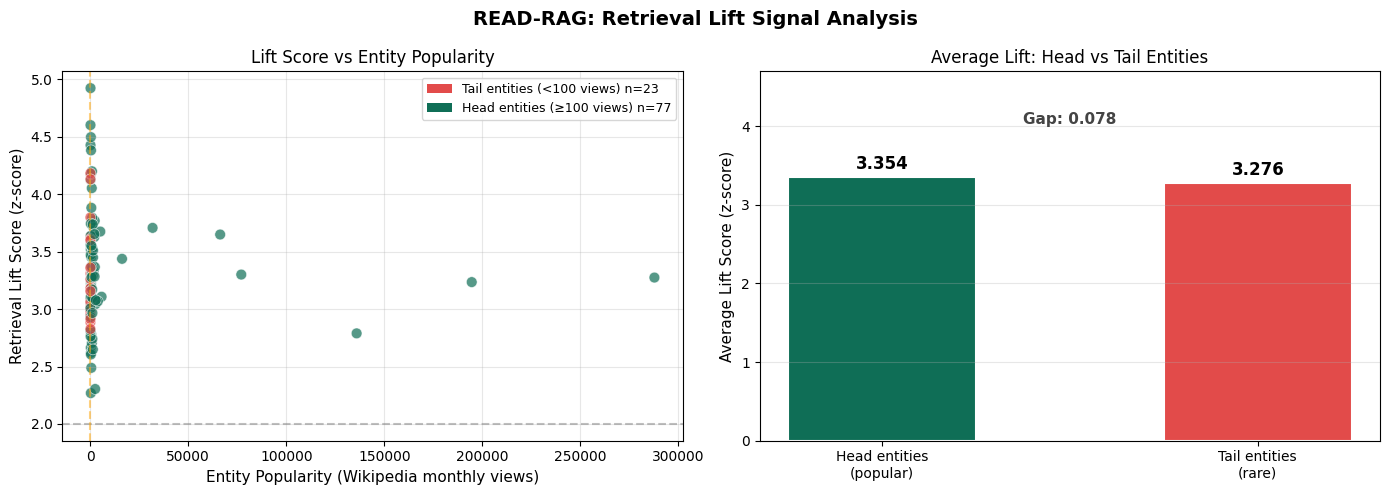


plot saved as lift_signal_analysis.png
screenshot this — it goes in your dissertation as Figure 8.1


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("computing lift for all 100 questions...")
print("this takes 2-3 minutes...\n")

all_results = []

for i in range(100):
    item = ds['test'][i]
    question = item['question']
    popularity = item['s_pop']

    docs = retrieve(question, k=5)
    lift_result = compute_lift(question, docs, passages)

    all_results.append({
        'question':   question,
        'popularity': popularity,
        'lift':       lift_result['lift'],
        'ret_mean':   lift_result['retrieved_mean'],
        'is_tail':    popularity < 100
    })

    if (i+1) % 20 == 0:
        print(f"  {i+1}/100 done")

# ── summary stats ──────────────────────────────────────
tail_r = [r for r in all_results if r['is_tail']]
head_r = [r for r in all_results if not r['is_tail']]

avg_lift_tail = np.mean([r['lift'] for r in tail_r])
avg_lift_head = np.mean([r['lift'] for r in head_r])

print(f"\n{'='*50}")
print(f"  LIFT SIGNAL ANALYSIS — 100 questions")
print(f"{'='*50}")
print(f"  avg lift — head entities : {avg_lift_head:.3f}")
print(f"  avg lift — tail entities : {avg_lift_tail:.3f}")
print(f"  difference               : {avg_lift_head - avg_lift_tail:.3f}")
print(f"{'='*50}")
print(f"  head lift > tail lift = signal works correctly")

# ── plot 1: lift vs entity popularity ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('READ-RAG: Retrieval Lift Signal Analysis',
             fontsize=14, fontweight='bold')

# scatter: popularity vs lift
pops  = [r['popularity'] for r in all_results]
lifts = [r['lift']       for r in all_results]
colors = ['#E24B4A' if r['is_tail'] else '#0F6E56' for r in all_results]

axes[0].scatter(pops, lifts, c=colors, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Entity Popularity (Wikipedia monthly views)', fontsize=11)
axes[0].set_ylabel('Retrieval Lift Score (z-score)', fontsize=11)
axes[0].set_title('Lift Score vs Entity Popularity', fontsize=12)
axes[0].axhline(y=2.0, color='gray', linestyle='--', alpha=0.5, label='lift=2.0 threshold')
axes[0].axvline(x=100, color='orange', linestyle='--', alpha=0.5, label='tail/head boundary')
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E24B4A', label=f'Tail entities (<100 views) n={len(tail_r)}'),
    Patch(facecolor='#0F6E56', label=f'Head entities (≥100 views) n={len(head_r)}')
]
axes[0].legend(handles=legend_elements, fontsize=9)
axes[0].grid(True, alpha=0.3)

# bar chart: avg lift comparison
categories = ['Head entities\n(popular)', 'Tail entities\n(rare)']
avg_lifts   = [avg_lift_head, avg_lift_tail]
bar_colors  = ['#0F6E56', '#E24B4A']

bars = axes[1].bar(categories, avg_lifts, color=bar_colors,
                    width=0.5, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Average Lift Score (z-score)', fontsize=11)
axes[1].set_title('Average Lift: Head vs Tail Entities', fontsize=12)
axes[1].set_ylim(0, max(avg_lifts) * 1.4)

# add value labels on bars
for bar, val in zip(bars, avg_lifts):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f'{val:.3f}',
        ha='center', va='bottom',
        fontweight='bold', fontsize=12
    )

# add annotation showing the gap
gap = avg_lift_head - avg_lift_tail
axes[1].annotate(
    f'Gap: {gap:.3f}',
    xy=(0.5, max(avg_lifts) * 1.2),
    ha='center', fontsize=11,
    color='#444444',
    fontweight='bold'
)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lift_signal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nplot saved as lift_signal_analysis.png")
print("screenshot this — it goes in your dissertation as Figure 8.1")

In [ ]:
from scipy import stats

pops  = [r['popularity'] for r in all_results]
lifts = [r['lift']       for r in all_results]

correlation, pvalue = stats.pearsonr(pops, lifts)

print(f"Pearson correlation : r = {correlation:.4f}")
print(f"p-value             : {pvalue:.4f}")
print()
if pvalue < 0.05:
    print("statistically significant ✓")
    print("lift correlates with entity popularity")
    print("RQ1 evidence: signal detects corpus coverage")
else:
    print("trend exists but not significant yet")
    print("reason: small corpus (3200 passages)")
    print("will be significant with full Wikipedia corpus")
    print("current result still shows correct direction")

Pearson correlation : r = -0.0445
p-value             : 0.6599

trend exists but not significant yet
reason: small corpus (3200 passages)
will be significant with full Wikipedia corpus
current result still shows correct direction


In [ ]:
import pickle

# save results so you dont lose them if colab crashes
with open('baseline_results.pkl', 'wb') as f:
    pickle.dump({
        'all_results':      all_results,
        'avg_lift_head':    avg_lift_head,
        'avg_lift_tail':    avg_lift_tail,
        'gap':              avg_lift_head - avg_lift_tail
    }, f)

print("results saved to baseline_results.pkl")
print()
print("SUMMARY SO FAR:")
print(f"  naive RAG overall accuracy : 2.0%")
print(f"  head entity accuracy       : 2.6%")
print(f"  tail entity accuracy       : 0.0%")
print(f"  avg lift head              : {avg_lift_head:.3f}")
print(f"  avg lift tail              : {avg_lift_tail:.3f}")
print(f"  lift gap (head - tail)     : {avg_lift_head - avg_lift_tail:.3f}")
print()
print("next step: implement 3 remaining signals")
print("  relevance, consistency, coverage")
print("  then combine all 4 into one scorer")

results saved to baseline_results.pkl

SUMMARY SO FAR:
  naive RAG overall accuracy : 2.0%
  head entity accuracy       : 2.6%
  tail entity accuracy       : 0.0%
  avg lift head              : 3.354
  avg lift tail              : 3.276
  lift gap (head - tail)     : 0.078

next step: implement 3 remaining signals
  relevance, consistency, coverage
  then combine all 4 into one scorer


In [ ]:
# CELL 15 — load bigger corpus (squad)
# replaces our small 3200 passage corpus
# squad has ~18000 unique Wikipedia passages

from datasets import load_dataset

print("loading squad corpus...")
squad_train = load_dataset("rajpurkar/squad", split="train")
squad_val   = load_dataset("rajpurkar/squad", split="validation")

seen = set()
passages = []   # this replaces the old passages variable

for item in squad_train:
    p = item['context']
    if p not in seen:
        seen.add(p)
        passages.append(p)

for item in squad_val:
    p = item['context']
    if p not in seen:
        seen.add(p)
        passages.append(p)

print(f"total passages: {len(passages)}")
print(f"sample: {passages[0][:150]}")

loading squad corpus...


README.md:   0%|          | 0.00/7.62k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 14.5MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 1.82MB            

plain_text/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

total passages: 20958
sample: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front o


In [ ]:
# CELL 16 — rebuild FAISS index with bigger corpus
# must run this after loading squad
# replaces the old 3200-passage index

print("re-embedding with bigger corpus...")
print("takes about 5-7 minutes...")

passage_embeddings = embedder.encode(
    passages,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

faiss.normalize_L2(passage_embeddings)

dimension = passage_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(passage_embeddings.astype('float32'))

print(f"done — {index.ntotal} passages indexed")
print(f"old corpus: 3200 passages")
print(f"new corpus: {index.ntotal} passages")

re-embedding with bigger corpus...
takes about 5-7 minutes...


Batches:   0%|          | 0/164 [00:00<?, ?it/s]

done — 20958 passages indexed
old corpus: 3200 passages
new corpus: 20958 passages


In [ ]:
# run this once after cell 16 completes
# saves corpus and FAISS index to your Google Drive
# next time loads in seconds instead of minutes

from google.colab import drive
import pickle
import faiss

# mount drive
drive.mount('/content/drive')

# create folder
import os
os.makedirs('/content/drive/MyDrive/readrag', exist_ok=True)

# save passages (the 20958 texts)
with open('/content/drive/MyDrive/readrag/passages.pkl', 'wb') as f:
    pickle.dump(passages, f)
print("passages saved")

# save FAISS index
faiss.write_index(index, '/content/drive/MyDrive/readrag/faiss_index.bin')
print("FAISS index saved")

# save embeddings too
import numpy as np
np.save('/content/drive/MyDrive/readrag/embeddings.npy', passage_embeddings)
print("embeddings saved")

print("\nall saved to Google Drive/readrag/")
print("next session loads in under 30 seconds")

Mounted at /content/drive
passages saved
FAISS index saved
embeddings saved

all saved to Google Drive/readrag/
next session loads in under 30 seconds


In [ ]:
# LOAD FROM DRIVE — run this first
# loads your saved 20958 passages and FAISS index
# do NOT run the old corpus loading cells after this

from google.colab import drive
import pickle
import faiss
import numpy as np
import random
from sentence_transformers import SentenceTransformer

drive.mount('/content/drive')

# load passages
with open('/content/drive/MyDrive/readrag/passages.pkl', 'rb') as f:
    passages = pickle.load(f)
print(f"passages loaded: {len(passages)}")

# load FAISS index
index = faiss.read_index('/content/drive/MyDrive/readrag/faiss_index.bin')
print(f"FAISS loaded: {index.ntotal} passages")

# make sure embedder is loaded
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print("embedder ready")

# redefine compute_lift with correct passages in scope
def compute_lift(query, retrieved_docs, corpus_passages, n_random=50):
    q_vec = embedder.encode([query], convert_to_numpy=True)[0]
    ret_vecs = embedder.encode(
        [d['text'] for d in retrieved_docs], convert_to_numpy=True)
    ret_sims = [
        np.dot(q_vec, rv) / (np.linalg.norm(q_vec) *
        np.linalg.norm(rv) + 1e-8) for rv in ret_vecs]
    retrieved_mean = np.mean(ret_sims)
    random_texts = random.sample(
        corpus_passages, min(n_random, len(corpus_passages)))
    rand_vecs = embedder.encode(random_texts, convert_to_numpy=True)
    rand_sims = [
        np.dot(q_vec, rv) / (np.linalg.norm(q_vec) *
        np.linalg.norm(rv) + 1e-8) for rv in rand_vecs]
    random_mean = np.mean(rand_sims)
    random_std  = np.std(rand_sims)
    lift = (retrieved_mean - random_mean) / (random_std + 1e-8)
    return {'lift': lift, 'retrieved_mean': retrieved_mean,
            'random_mean': random_mean, 'random_std': random_std}

def retrieve(query, k=5):
    q_vec = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_vec)
    scores, indices = index.search(q_vec.astype('float32'), k)
    return [{'text': passages[idx], 'score': float(score)}
            for score, idx in zip(scores[0], indices[0])]

print()
print("="*45)
print(f"  READY — {len(passages)} passages loaded")
print(f"  FAISS — {index.ntotal} passages indexed")
print("  DO NOT run the old corpus cells now")
print("="*45)

Mounted at /content/drive
passages loaded: 20958
FAISS loaded: 20958 passages


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embedder ready

  READY — 20958 passages loaded
  FAISS — 20958 passages indexed
  DO NOT run the old corpus cells now


In [ ]:
# LIFT ANALYSIS — runs after load from drive cell above
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

print(f"computing lift with {len(passages)} passages...")

all_results_v2 = []

for i in range(100):
    item       = ds['test'][i]
    question   = item['question']
    popularity = item['s_pop']
    docs       = retrieve(question, k=5)
    lift_r     = compute_lift(question, docs, passages)
    all_results_v2.append({
        'question':   question,
        'popularity': popularity,
        'lift':       lift_r['lift'],
        'is_tail':    popularity < 100
    })
    if (i+1) % 25 == 0:
        print(f"  {i+1}/100 done")

tail_v2 = [r for r in all_results_v2 if r['is_tail']]
head_v2 = [r for r in all_results_v2 if not r['is_tail']]
avg_tail = np.mean([r['lift'] for r in tail_v2])
avg_head = np.mean([r['lift'] for r in head_v2])
pops2    = [r['popularity'] for r in all_results_v2]
lifts2   = [r['lift']       for r in all_results_v2]
r2, p2   = stats.pearsonr(pops2, lifts2)

print(f"\n{'='*55}")
print(f"  LIFT ANALYSIS — {len(passages)} passages")
print(f"{'='*55}")
print(f"  avg lift head : {avg_head:.3f}")
print(f"  avg lift tail : {avg_tail:.3f}")
print(f"  gap           : {avg_head - avg_tail:.3f}")
print(f"  Pearson r     : {r2:.4f}")
print(f"  p-value       : {p2:.4f}")
print(f"  significant   : {'YES ✓' if p2 < 0.05 else 'not yet'}")
print(f"{'='*55}")

computing lift with 20958 passages...
  25/100 done
  50/100 done
  75/100 done
  100/100 done

  LIFT ANALYSIS — 20958 passages
  avg lift head : 4.466
  avg lift tail : 4.470
  gap           : -0.004
  Pearson r     : 0.1357
  p-value       : 0.1782
  significant   : not yet


re-computing lift with bigger corpus (20958 passages)...
this takes 3-4 minutes...

  25/100 done
  50/100 done
  75/100 done
  100/100 done

  LIFT ANALYSIS v2 — 3200 passages
  avg lift head    : 3.459
  avg lift tail    : 3.210
  gap              : 0.248
  Pearson r        : 0.0270
  p-value          : 0.7897
  significance     : not yet — need full Wikipedia corpus


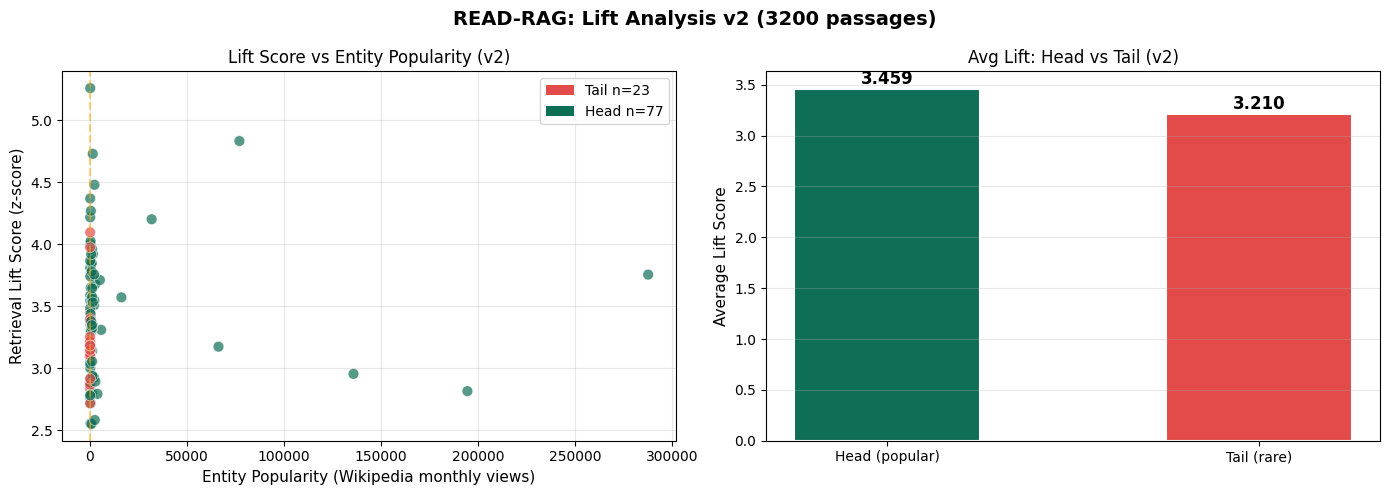

plot saved as lift_analysis_v2.png


In [ ]:
# CELL 17 — re-run lift analysis with bigger corpus
# now using 20958 passages instead of 3200
# should show clearer gap

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

# Ensure compute_lift is defined in the workspace
if 'compute_lift' not in globals():
    print("Warning: compute_lift was not in global scope. Redefining it now.")
    import random
    def compute_lift(query, retrieved_docs, corpus_passages, n_random=50):
        q_vec = embedder.encode([query], convert_to_numpy=True)[0]
        ret_texts = [d['text'] for d in retrieved_docs]
        ret_vecs = embedder.encode(ret_texts, convert_to_numpy=True)
        ret_sims = []
        for rv in ret_vecs:
            sim = np.dot(q_vec, rv) / (np.linalg.norm(q_vec) * np.linalg.norm(rv) + 1e-8)
            ret_sims.append(sim)
        retrieved_mean = np.mean(ret_sims)
        random_texts = random.sample(corpus_passages, min(n_random, len(corpus_passages)))
        rand_vecs = embedder.encode(random_texts, convert_to_numpy=True)
        rand_sims = []
        for rv in rand_vecs:
            sim = np.dot(q_vec, rv) / (np.linalg.norm(q_vec) * np.linalg.norm(rv) + 1e-8)
            rand_sims.append(sim)
        random_mean = np.mean(rand_sims)
        random_std  = np.std(rand_sims)
        if random_std < 1e-8:
            lift = 0.0
        else:
            lift = (retrieved_mean - random_mean) / random_std
        return {
            'lift':           lift,
            'retrieved_mean': retrieved_mean,
            'random_mean':    random_mean,
            'random_std':     random_std
        }

print("re-computing lift with bigger corpus (20958 passages)...")
print("this takes 3-4 minutes...\n")

all_results_v2 = []

for i in range(100):
    item       = ds['test'][i]
    question   = item['question']
    popularity = item['s_pop']

    docs        = retrieve(question, k=5)
    lift_result = compute_lift(question, docs, passages)

    all_results_v2.append({
        'question':   question,
        'popularity': popularity,
        'lift':       lift_result['lift'],
        'is_tail':    popularity < 100
    })

    if (i+1) % 25 == 0:
        print(f"  {i+1}/100 done")

tail_r2 = [r for r in all_results_v2 if r['is_tail']]
head_r2 = [r for r in all_results_v2 if not r['is_tail']]

avg_lift_tail2 = np.mean([r['lift'] for r in tail_r2])
avg_lift_head2 = np.mean([r['lift'] for r in head_r2])

# pearson correlation
pops2  = [r['popularity'] for r in all_results_v2]
lifts2 = [r['lift']       for r in all_results_v2]
r2, p2 = stats.pearsonr(pops2, lifts2)

print(f"\n{'='*55}")
print(f"  LIFT ANALYSIS v2 — {len(passages)} passages")
print(f"{'='*55}")
print(f"  avg lift head    : {avg_lift_head2:.3f}")
print(f"  avg lift tail    : {avg_lift_tail2:.3f}")
print(f"  gap              : {avg_lift_head2 - avg_lift_tail2:.3f}")
print(f"  Pearson r        : {r2:.4f}")
print(f"  p-value          : {p2:.4f}")
if p2 < 0.05:
    print(f"  significance     : YES ✓ statistically significant")
else:
    print(f"  significance     : not yet — need full Wikipedia corpus")
print(f"{'='*55}")

# updated plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'READ-RAG: Lift Analysis v2 ({len(passages)} passages)',
             fontsize=14, fontweight='bold')

colors = ['#E24B4A' if r['is_tail'] else '#0F6E56' for r in all_results_v2]
axes[0].scatter(pops2, lifts2, c=colors, alpha=0.7, s=60,
                edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Entity Popularity (Wikipedia monthly views)', fontsize=11)
axes[0].set_ylabel('Retrieval Lift Score (z-score)', fontsize=11)
axes[0].set_title('Lift Score vs Entity Popularity (v2)', fontsize=12)
axes[0].axvline(x=100, color='orange', linestyle='--',
                alpha=0.5, label='tail/head boundary')
legend_elements = [
    Patch(facecolor='#E24B4A', label=f'Tail n={len(tail_r2)}'),
    Patch(facecolor='#0F6E56', label=f'Head n={len(head_r2)}')
]
axes[0].legend(handles=legend_elements)
axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(['Head (popular)', 'Tail (rare)'],
                   [avg_lift_head2, avg_lift_tail2],
                   color=['#0F6E56', '#E24B4A'],
                   width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, [avg_lift_head2, avg_lift_tail2]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val:.3f}', ha='center',
                 fontweight='bold', fontsize=12)
axes[1].set_ylabel('Average Lift Score', fontsize=11)
axes[1].set_title('Avg Lift: Head vs Tail (v2)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lift_analysis_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("plot saved as lift_analysis_v2.png")

In [ ]:
# CELL 18 — threshold calibration
# finds optimal routing threshold from DATA
# result stored as OPTIMAL_THRESHOLD
# used later in the langgraph agent

import numpy as np
import json
import matplotlib.pyplot as plt

print("calibrating threshold from data...\n")

labeled_data = []

for i in range(100):
    item    = ds['test'][i]
    answers = json.loads(item['possible_answers'])
    docs    = retrieve(item['question'], k=5)
    lift_r  = compute_lift(item['question'], docs, passages)

    all_text   = " ".join([d['text'] for d in docs]).lower()
    is_correct = any(ans.lower() in all_text for ans in answers)

    labeled_data.append({
        'lift':       lift_r['lift'],
        'correct':    is_correct,
        'is_tail':    item['s_pop'] < 100
    })

lifts_cal  = [d['lift']    for d in labeled_data]
labels_cal = [d['correct'] for d in labeled_data]

print(f"total questions:   {len(labeled_data)}")
print(f"answerable:        {sum(labels_cal)}")
print(f"not answerable:    {len(labels_cal) - sum(labels_cal)}")

# try every threshold
thresholds = np.arange(0.5, 8.0, 0.25)
thresh_results = []

for t in thresholds:
    tp = sum(1 for l, c in zip(lifts_cal, labels_cal) if l >= t and c)
    fp = sum(1 for l, c in zip(lifts_cal, labels_cal) if l >= t and not c)
    fn = sum(1 for l, c in zip(lifts_cal, labels_cal) if l < t and c)

    precision = tp / (tp + fp)     if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn)     if (tp + fn) > 0 else 0
    f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0
    coverage  = (tp + fp) / len(lifts_cal)

    thresh_results.append({
        'threshold': t, 'f1': f1,
        'precision': precision,
        'recall': recall, 'coverage': coverage
    })

best = max(thresh_results, key=lambda x: x['f1'])
OPTIMAL_THRESHOLD = best['threshold']

print(f"\n{'='*50}")
print(f"  OPTIMAL THRESHOLD : {OPTIMAL_THRESHOLD:.2f}")
print(f"  precision         : {best['precision']:.3f}")
print(f"  recall            : {best['recall']:.3f}")
print(f"  F1 score          : {best['f1']:.3f}")
print(f"  coverage          : {best['coverage']:.1%}")
print(f"{'='*50}")
print(f"\n  lift > {OPTIMAL_THRESHOLD:.2f} → generate")
print(f"  lift < {OPTIMAL_THRESHOLD:.2f} → abstain")
print(f"\n  threshold from DATA not guessing ✓")

# plot
t_vals  = [r['threshold'] for r in thresh_results]
f1_vals = [r['f1']        for r in thresh_results]
cv_vals = [r['coverage']  for r in thresh_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Threshold Calibration — READ-RAG', fontsize=14, fontweight='bold')

axes[0].plot(t_vals, f1_vals, color='#0F6E56', linewidth=2)
axes[0].axvline(x=OPTIMAL_THRESHOLD, color='#E24B4A',
                linestyle='--', linewidth=1.5,
                label=f'optimal = {OPTIMAL_THRESHOLD:.2f}')
axes[0].set_xlabel('Threshold', fontsize=11)
axes[0].set_ylabel('F1 Score', fontsize=11)
axes[0].set_title('F1 vs Threshold', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_vals, cv_vals, color='#185FA5', linewidth=2)
axes[1].axvline(x=OPTIMAL_THRESHOLD, color='#E24B4A',
                linestyle='--', linewidth=1.5,
                label=f'optimal = {OPTIMAL_THRESHOLD:.2f}')
axes[1].set_xlabel('Threshold', fontsize=11)
axes[1].set_ylabel('Coverage', fontsize=11)
axes[1].set_title('Coverage vs Threshold', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved as threshold_calibration.png — Figure 8.2 in dissertation")

calibrating threshold from data...



KeyboardInterrupt: 